In [1]:
from src import DataPreprocessor

# Load the data
file_path = 'datasets/mall_customers.csv'
preprocessor = DataPreprocessor(file_path)
df = preprocessor.load_data()
head, info = preprocessor.inspect_data()

print("Data Head:")
print(head)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Data Head:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


#### Παρατηρούμε:
    Έχουμε μικρό dataset (200 εγγραφές).Θα πρέπει να το έχουμε υπ'όψη γιατί θα επηρεάσει την εγκυρότητα των μοντέλων
    Δεν χρειάζεται να ελέγξουμε για null values.
#### Θα εξαλείψουμε τυχόν περίεργες τιμές και outliers, εστιάζοντας στις στήλες Annual Income και Spending Score

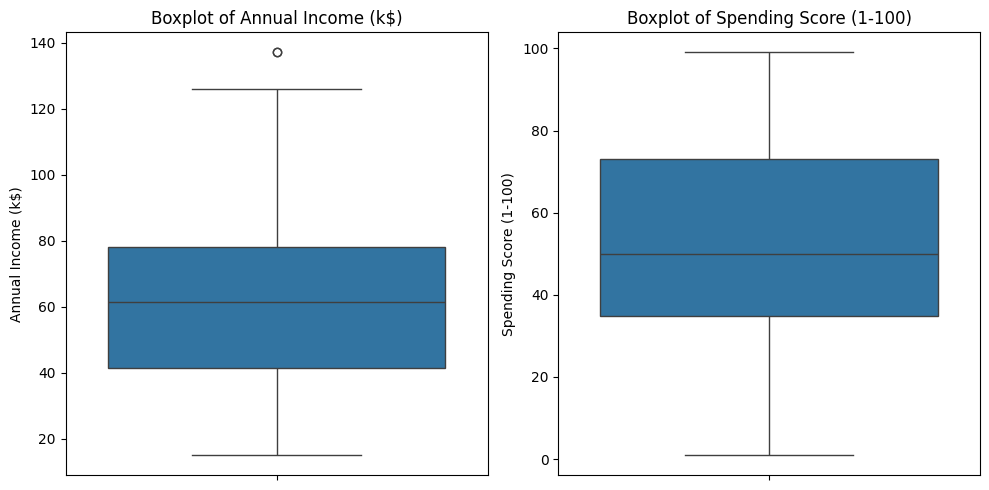

Original Row Count: 200
Rows Removed: 2
Current Row Count: 198
Outliers were detected and removed.


In [2]:
# Columns to check
cols_to_check = ['Annual Income (k$)', 'Spending Score (1-100)']

# 1. Visualize first (to see if there are "crazy" outliers)
preprocessor.plot_boxplots(cols_to_check)

# 2. Remove outliers
df_clean = preprocessor.remove_outliers(cols_to_check)

# We calculate the removed count
original_count = 200 # or len(preprocessor.data)
removed_count = original_count - len(df_clean)

print(f"Original Row Count: {original_count}")
print(f"Rows Removed: {removed_count}")
print(f"Current Row Count: {len(df_clean)}")

if removed_count > 0:
    print("Outliers were detected and removed.")
else:
    print("No outliers detected based on 1.5 IQR threshold.")

#### Παρατηρούμε πως διαγράφηκαν 2 εγγραφές.
    Τη μία απο αυτές την βλέπουμε και στο πρώτο boxplot. Πρόκειται για πολύ υψηλή τιμή  εισοδήματος.
#### Στη συνέχεια θα κάνουμε feature selection.
    Πρώτα θα υπολογίσουμε το correlation coefficient μεταξύ Age, Gender και Spending Score. Μετά θα αποφασίσουμε αν θα συμπεριλάβουμε
    τα Age, Gender στη διαδικασία του clustering.

Correlation Matrix:
                             Age  Gender_Num  Spending Score (1-100)
Age                     1.000000   -0.067835               -0.329421
Gender_Num             -0.067835    1.000000                0.059092
Spending Score (1-100) -0.329421    0.059092                1.000000


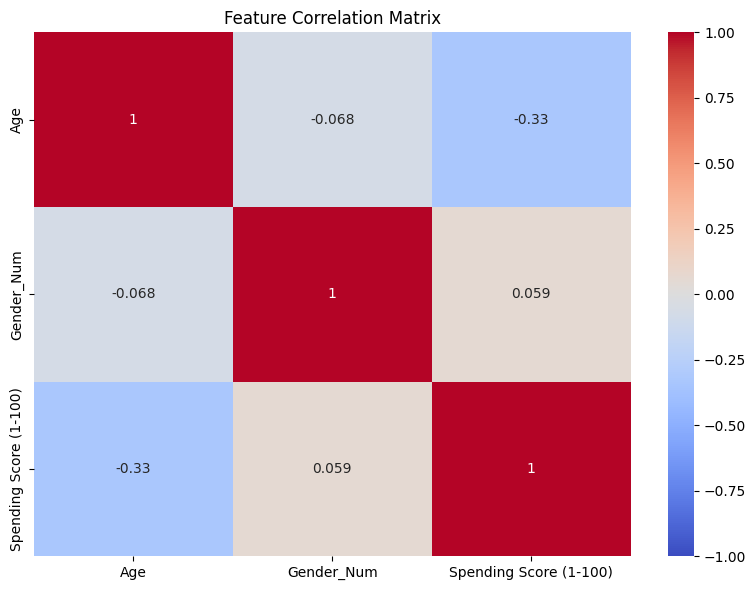

In [3]:
from  src import FeatureAnalyzer

analyzer = FeatureAnalyzer(df_clean)

# Map gender to 0 for 'Male' and 1 for 'Female'
analyzer.encode_categorical()

# Columns: Age, Gender (Encoded), Spending Score
cols_to_analyze = ['Age', 'Gender_Num', 'Spending Score (1-100)']

corr_matrix = analyzer.compute_correlations(cols_to_analyze)
analyzer.plot_heatmap(corr_matrix)

print("Correlation Matrix:")
print(corr_matrix)

#### Παρατηρήσεις:
    - Age vs. Spending Score (-0.33). Η ηλικία παρουσιάζει ελαφρώς αρνητική συσχέτιση με το Spending Score. Αυτό μας δείχνει πως
      οι νεότερες ηλικίες συνηθίζουν να ξοδεύουν περισσότερα χρήματα κατά μέσο όρο. Είναι σημαντικό εύρημα.
    - Gender vs. Spending Score (0.06). Η συσχέτιση μεταξύ φύλου και spending score είναι σχεδόν μηδενική.
#### Βασιζόμενοι στα ανωτέρω ευρήματα θα συμπεριλάβουμε την ηλικία στη διαδικασία του clustering
     Επειδή ο KMeans είναι distance based αλγόριθμος, πρώτα θα κάνουμε scale τα δεδομένα και μετα θα τον τρέξουμε.

In [4]:
import numpy as np
from matplotlib import pyplot as plt
from src import DataPreprocessor, ClusterModeler, ClusterVisualizer

# Features to use
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# 1. Test StandardScaler (Method A)
print("Running optimization with StandardScaler...")
prep_std = DataPreprocessor(file_path, scaler_type='standard')
prep_std.load_data()
X_std = prep_std.get_scaled_features(features)

modeler_std = ClusterModeler(X_std)
inertia_std, sil_std = modeler_std.find_optimal_k()

# 2. Test MinMaxScaler (Method B)
print("Running optimization with MinMaxScaler...")
prep_mm = DataPreprocessor(file_path, scaler_type='minmax')
prep_mm.load_data()
X_mm = prep_mm.get_scaled_features(features)

modeler_mm = ClusterModeler(X_mm)
inertia_mm, sil_mm = modeler_mm.find_optimal_k()

#  Run KMeans
print(f"Running Simple KMeans ...")

k_value = 6
modeler = ClusterModeler(X_std)
labels = modeler.train_model(k_value)

Running optimization with StandardScaler...
Running optimization with MinMaxScaler...
Running Simple KMeans ...


#### Θα αναζητήσουμε τη βέλτιστη τιμή του k μέσω της μεθόδου elbow και θα την επαληθεύσουμε μέσω του Silhouette Score.


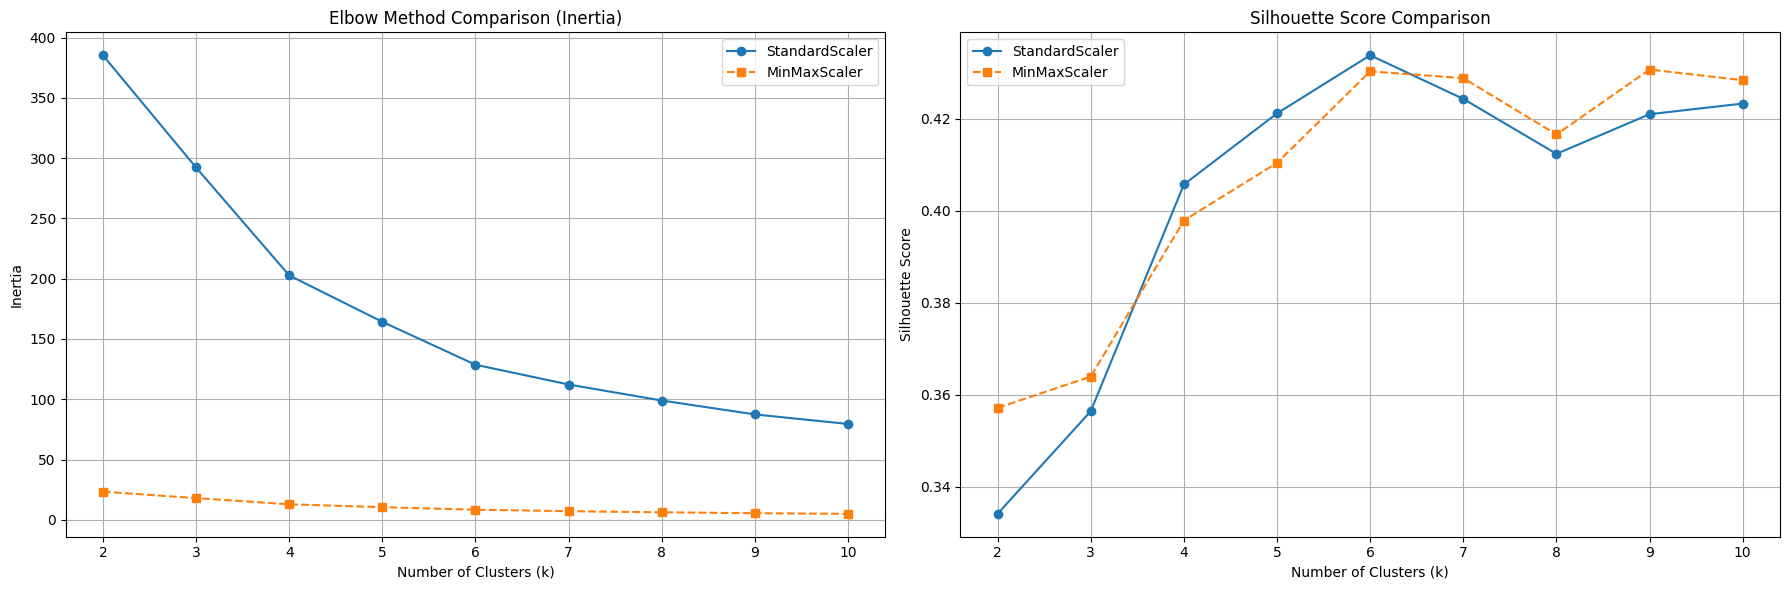


Comparison Table:
K     | Std Silhouette  | MinMax Silhouette
---------------------------------------------
2     | 0.3341          | 0.3571         
3     | 0.3564          | 0.3639         
4     | 0.4057          | 0.3979         
5     | 0.4212          | 0.4104         
6     | 0.4338          | 0.4303         
7     | 0.4243          | 0.4289         
8     | 0.4124          | 0.4166         
9     | 0.4210          | 0.4307         
10    | 0.4233          | 0.4284         

Optimal K (StandardScaler): 6 (Score: 0.4338)
Optimal K (MinMaxScaler):   9 (Score: 0.4307)


In [5]:
# Visualization: Side-by-Side Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot Elbow (Inertia)
ax1.plot(modeler_std.k_range, inertia_std, marker='o', linestyle='-', label='StandardScaler')
# Normalize MinMax inertia for visual comparison or plot on secondary axis?
# Usually better to just plot raw to see the curve shape.
ax1.plot(modeler_mm.k_range, inertia_mm, marker='s', linestyle='--', label='MinMaxScaler')
ax1.set_title('Elbow Method Comparison (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.legend()
ax1.grid(True)

# Plot Silhouette Score
ax2.plot(modeler_std.k_range, sil_std, marker='o', linestyle='-', label='StandardScaler')
ax2.plot(modeler_mm.k_range, sil_mm, marker='s', linestyle='--', label='MinMaxScaler')
ax2.set_title('Silhouette Score Comparison')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 4. Print Comparison Table
print("\nComparison Table:")
print(f"{'K':<5} | {'Std Silhouette':<15} | {'MinMax Silhouette':<15}")
print("-" * 45)
for k, s_std, s_mm in zip(modeler_std.k_range, sil_std, sil_mm):
    print(f"{k:<5} | {s_std:<15.4f} | {s_mm:<15.4f}")

best_k_std = modeler_std.k_range[np.argmax(sil_std)]
best_k_mm = modeler_mm.k_range[np.argmax(sil_mm)]

print(f"\nOptimal K (StandardScaler): {best_k_std} (Score: {max(sil_std):.4f})")
print(f"Optimal K (MinMaxScaler):   {best_k_mm} (Score: {max(sil_mm):.4f})")

#### Μετά από την παρατήρηση των διαγραμμάτων και του πίνακα κρίνουμε πως το βέλτιστο k = 6.
#### Στη συνέχεια θα ρυθμίσουμε τις παραμέτρους του μοντέλου ώστε να επιτύχουμε καλύτερη απόδοση.

In [6]:
from src import ClusterModeler

# Define the Hyperparameter Grid to search
param_grid = {
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 50],
    'max_iter': [300, 500],
    'algorithm': ['lloyd', 'elkan']
}

# Initialize Modeler with Scaled Data (X_scaled) and Optimal K (6)
X_scaled = preprocessor.get_scaled_features(features)
modeler = ClusterModeler(X_scaled)

# Run the tuning (k=6)
tuning_results = modeler.tune_parameters(k=6, param_grid=param_grid)

# --- Display Results ---
print("\nTop 5 Hyperparameter Combinations:")
print(tuning_results.head(5))

print("\nBest Parameters found:")
best_params = tuning_results.iloc[0]
print(best_params)

Tuning KMeans for K=6...

Top 5 Hyperparameter Combinations:
         init  n_init  max_iter algorithm  Silhouette Score
12     random      10       300     lloyd          0.436898
13     random      10       300     elkan          0.436898
14     random      10       500     lloyd          0.436898
15     random      10       500     elkan          0.436898
0   k-means++      10       300     lloyd          0.433836

Best Parameters found:
init                  random
n_init                    10
max_iter                 300
algorithm              lloyd
Silhouette Score    0.436898
Name: 12, dtype: object


#### Τρέχουμε ξανά τον KMeans αλγόριθμο, εισάγοντας τις βέλτιστες παραμέτρους που μόλις βρήκαμε.

In [7]:
from sklearn.cluster import KMeans

# Remove the 'Silhouette Score' key since KMeans doesn't need it
if 'Silhouette Score' in best_params:
    del best_params['Silhouette Score']

print(f"Training final model with K=6 and parameters:\n {best_params}")

# Train the Final Model
# Unpack (**best_params) to pass arguments like init='random', n_init=10, etc.
final_model = KMeans(n_clusters=6, random_state=42, **best_params)
final_labels = final_model.fit_predict(X_scaled)

# Assign Labels to the Cleaned Data
# We access the df_clean from the preprocessor to ensure indices match
df_final = preprocessor.df_clean.copy()
df_final['Cluster'] = final_labels

Training final model with K=6 and parameters:
 init         random
n_init           10
max_iter        300
algorithm     lloyd
Name: 12, dtype: object


#### Στη συνέχεια θα οπτικοποιήσουμε τα αποτελέσματα του clustering.

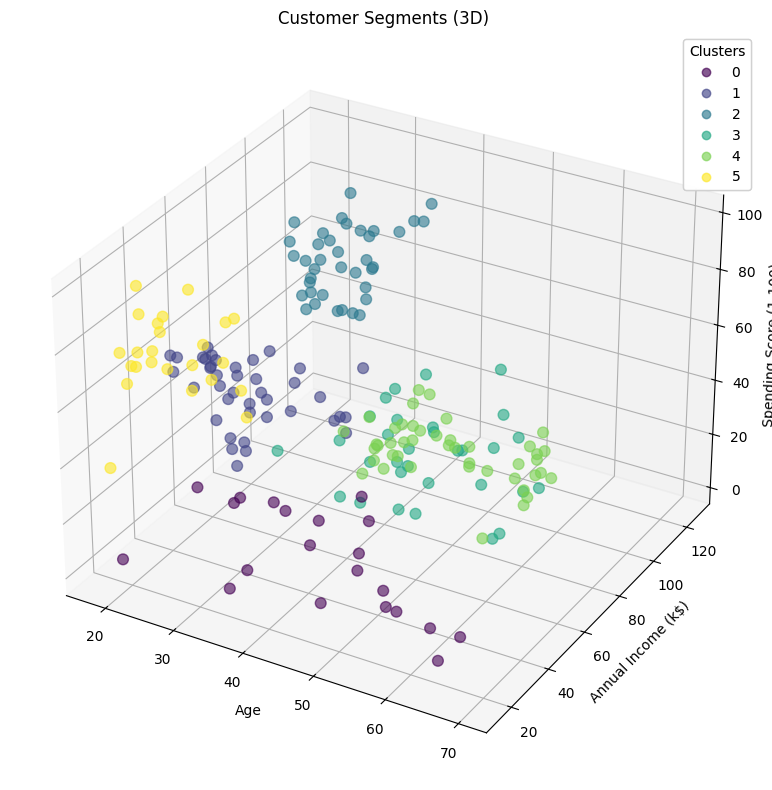

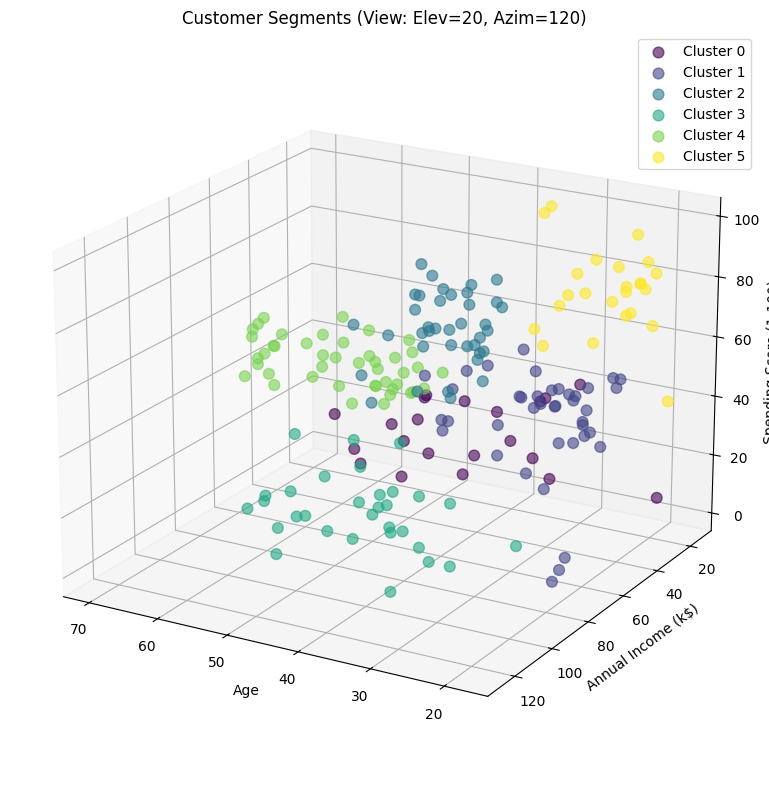


Final Clustering Complete.
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        5  
1        5  
2        0  
3        5  
4        0  


In [10]:
from src import ClusterVisualizer

visualizer = ClusterVisualizer()
visualizer.plot_clusters_3d(df_final, final_labels, features)
visualizer.plot_rotated_clusters(df_final, final_labels, features, elev=20, azim=120)

print("\nFinal Clustering Complete.")
print(df_final.head())

#### Θα εντοπίσουμε το cluster με το υψηλότερο spending score.

Clusters sorted by Average Spending Score (Highest to Lowest):
   Cluster        Age  Annual Income (k$)  Spending Score (1-100)
2        2  32.763158           85.210526               82.105263
5        5  25.250000           25.833333               76.916667
4        4  56.340909           53.704545               49.386364
1        1  26.325000           58.550000               45.650000
0        0  45.523810           26.285714               19.380952
3        3  44.161290           87.838710               18.290323


C:\Users\Kostas\AppData\Local\Temp\ipykernel_15404\3468036931.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=df_final, palette='viridis')


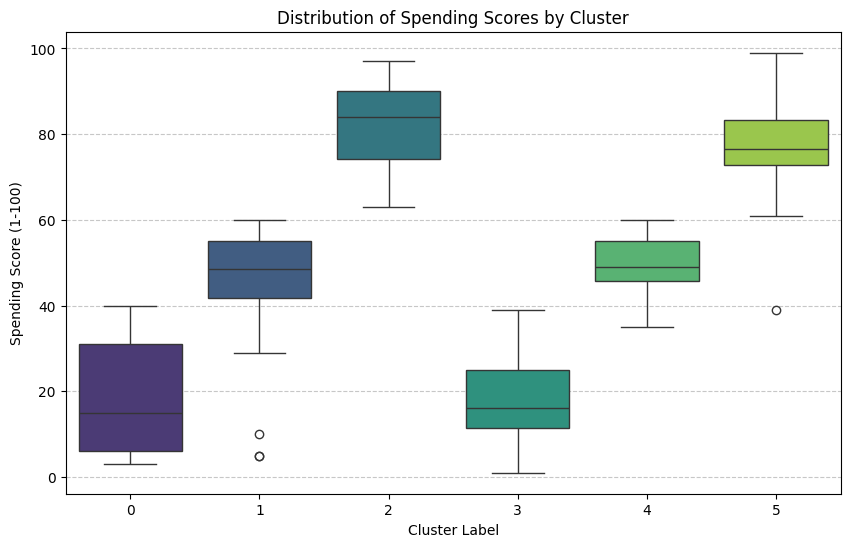


Conclusion: Cluster 2 is the highest spending group with an average score of 82.11.


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the mean values for each cluster
# This helps us define "who" belongs to each cluster (e.g., "Young, High Income, High Spending")
cluster_summary = df_final.groupby('Cluster')[features].mean().reset_index()

# 2. Sort by Spending Score to find the top clusters
high_spending_clusters = cluster_summary.sort_values(by='Spending Score (1-100)', ascending=False)

print("Clusters sorted by Average Spending Score (Highest to Lowest):")
print(high_spending_clusters)

# 3. Visual Confirmation: Boxplot
# This shows the range of spending scores for each cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=df_final, palette='viridis')
plt.title('Distribution of Spending Scores by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Spending Score (1-100)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Programmatic Identification
top_cluster = high_spending_clusters.iloc[0]['Cluster']
top_score = high_spending_clusters.iloc[0]['Spending Score (1-100)']
print(f"\nConclusion: Cluster {int(top_cluster)} is the highest spending group with an average score of {top_score:.2f}.")